# Notebook 05 — LTR Dataset Reformulation

Convert feature-engineered task datasets into candidate `(Task_ID, Employee_ID)` pairs for learning-to-rank.

**Each row:** one task + one candidate employee + one relevance label.

> **Implicit-negative note:** Employees not historically assigned to a task are treated as implicit negatives. This means the assignment was not observed, not that the employee was definitively unsuitable.

## Step 1 — Imports and Load Inputs

In [84]:
import pandas as pd
import numpy as np
import json
import os
import warnings
import datetime
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
NEGATIVES_PER_TASK = 20
np.random.seed(RANDOM_STATE)

DATA_DIR   = "../data/processed/split_datasets"
OUTPUT_DIR = "../data/processed/ltr_datasets"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(f"{DATA_DIR}/feature_engineered_train_dataset.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/feature_engineered_validation_dataset.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/feature_engineered_test_dataset.csv")

employee_skill_profiles      = pd.read_csv(f"{DATA_DIR}/employee_skill_profiles.csv")
employee_historical_profiles = pd.read_csv(f"{DATA_DIR}/employee_historical_profiles.csv")

with open(f"{DATA_DIR}/model_metadata.json") as f:
    metadata = json.load(f)

SKILL_COLUMNS        = metadata["task_skill_columns"]
EMP_SKILL_PROFILE_COLS = metadata["employee_skill_profile_cols"]

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print(f"Employee skill profiles: {employee_skill_profiles.shape}")
print(f"Employee historical profiles: {employee_historical_profiles.shape}")
print(f"Skill columns: {SKILL_COLUMNS}")

Train: (8314, 45), Val: (1588, 45), Test: (1728, 45)
Employee skill profiles: (49, 10)
Employee historical profiles: (49, 9)
Skill columns: ['Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship']


## Step 2 — Define Leakage Columns

In [85]:
LEAKAGE_COLS = [
    "Actual_Hours_Spent", "Timesheet_Work_Logs", "Timesheet_Logs_Count",
    "Task_Stage", "All_Collaborating_Employees", "Work_Description",
    "Employee_Name", "Assigned_Employee_Name", "Assigned_Employee_ID",
    "Debug_Skill_Scores", "Task_Skills",
]

for dset in [train_df, val_df, test_df]:
    drop = [c for c in LEAKAGE_COLS if c in dset.columns]
    dset.drop(columns=drop, inplace=True)

print(f"Leakage columns dropped. Train columns remaining: {train_df.shape[1]}")

Leakage columns dropped. Train columns remaining: 45


## Step 3 — Verify Task-Level Split (No Leakage)

In [86]:
train_tasks = set(train_df["Task_ID"])
val_tasks   = set(val_df["Task_ID"])
test_tasks  = set(test_df["Task_ID"])

train_val_overlap  = train_tasks.intersection(val_tasks)
train_test_overlap = train_tasks.intersection(test_tasks)
val_test_overlap   = val_tasks.intersection(test_tasks)

print("Train unique tasks:      ", len(train_tasks))
print("Validation unique tasks: ", len(val_tasks))
print("Test unique tasks:       ", len(test_tasks))
print("Train/Validation task overlap:", len(train_val_overlap))
print("Train/Test task overlap:      ", len(train_test_overlap))
print("Validation/Test task overlap: ", len(val_test_overlap))

assert len(train_val_overlap)  == 0, "LEAKAGE: Train/Val!"
assert len(train_test_overlap) == 0, "LEAKAGE: Train/Test!"
assert len(val_test_overlap)   == 0, "LEAKAGE: Val/Test!"
print("All task-leakage assertions passed!")

Train unique tasks:       1709
Validation unique tasks:  366
Test unique tasks:        367
Train/Validation task overlap: 0
Train/Test task overlap:       0
Validation/Test task overlap:  0
All task-leakage assertions passed!


## Step 4 — Define Candidate Pool

In [87]:
TRAIN_EMPLOYEES = sorted(train_df["Employee_ID"].unique())
N_EMPLOYEES = len(TRAIN_EMPLOYEES)
print(f"Candidate pool: {N_EMPLOYEES} employees (training data only)")

cold_start_summary = {}
for name, dset in [("val", val_df), ("test", test_df)]:
    missing = set(dset["Employee_ID"].unique()) - set(TRAIN_EMPLOYEES)
    cold_start_summary[name] = sorted(missing)
    if missing:
        print(f"Cold-start employees in {name} (not in train): {sorted(missing)}")
    else:
        print(f"{name}: all employees present in training pool")

candidate_pool = pd.DataFrame({
    "Employee_ID": TRAIN_EMPLOYEES,
    "in_training": True,
})
candidate_pool.to_csv(f"{OUTPUT_DIR}/employee_candidate_pool.csv", index=False)
print(f"employee_candidate_pool.csv saved: {candidate_pool.shape}")

Candidate pool: 49 employees (training data only)
val: all employees present in training pool
test: all employees present in training pool
employee_candidate_pool.csv saved: (49, 2)


## Step 5 — Extract Task-Level Features

In [88]:
NON_TASK_COLS = [
    "Employee_ID", "Employee_Name", "Employee_Department",
    "Employee_Job_Position", "Task_Text", "Task_Name",
    "Task_Description", "Date", "Created_Date", "Deadline_Date",
    "Project_Name",
]

def get_task_features(dset):
    keep = [c for c in dset.columns if c not in NON_TASK_COLS]
    return dset.groupby("Task_ID")[keep].first().reset_index()

NON_TASK_COLS = [
    "Employee_ID", "Employee_Name", "Employee_Department",
    "Employee_Job_Position", "Task_Text", "Task_Name",
    "Task_Description", "Date", "Created_Date", "Deadline_Date",
    "Project_Name",
]

def get_task_features(dset):
    keep = [
        c for c in dset.columns
        if c not in NON_TASK_COLS and c != "Task_ID"
    ]
    return dset.groupby("Task_ID")[keep].first().reset_index()

task_feat_train = get_task_features(train_df)
task_feat_val   = get_task_features(val_df)
task_feat_test  = get_task_features(test_df)

print(f"Task features — train: {task_feat_train.shape}, val: {task_feat_val.shape}, test: {task_feat_test.shape}")
print(f"Task feature columns ({len(task_feat_train.columns)}): {list(task_feat_train.columns)}")

Task features — train: (1709, 35), val: (366, 35), test: (367, 35)
Task feature columns (35): ['Task_ID', 'Hours_Spent', 'FLAG_LEAKAGE_Timesheet_Work_Logs', 'Task_Priority', 'Estimated_Planned_Hours', 'FLAG_LEAKAGE_Actual_Hours_Spent', 'FLAG_LEAKAGE_Timesheet_Logs_Count', 'FLAG_LEAKAGE_Task_Stage', 'FLAG_LEAKAGE_All_Collaborating_Employees', 'Task_Text_Length', 'Task_Word_Count', 'Task_Description_Length', 'Task_Name_Length', 'Has_Task_Description', 'Created_Year', 'Created_Month', 'Created_DayOfWeek', 'Created_Quarter', 'Days_To_Deadline', 'Has_Deadline', 'Planned_Hours_Log', 'Planned_Task_Size', 'Task_Skill_Count', 'Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_Avg_Planned_Hours_Train']


## Step 6 — Build Positive Assignments

In [89]:
def get_positive_assignments(dset):
    pos = dset[["Task_ID", "Employee_ID"]].drop_duplicates().copy()
    pos["relevance"] = 1
    return pos

pos_train = get_positive_assignments(train_df)
pos_val   = get_positive_assignments(val_df)
pos_test  = get_positive_assignments(test_df)

print(f"Positive pairs — train: {len(pos_train)}, val: {len(pos_val)}, test: {len(pos_test)}")
for name, pos in [("train", pos_train), ("val", pos_val), ("test", pos_test)]:
    multi = pos.groupby("Task_ID")["Employee_ID"].count()
    print(f"  {name}: {(multi > 1).sum()} tasks have multiple positive employees")

Positive pairs — train: 2425, val: 509, test: 487
  train: 315 tasks have multiple positive employees
  val: 71 tasks have multiple positive employees
  test: 56 tasks have multiple positive employees


## Step 7 — Smart Negative Sampling

In [90]:
rng = np.random.default_rng(RANDOM_STATE)

def build_candidate_pairs(pos_df, employee_pool, name, neg_per_task=NEGATIVES_PER_TASK):
    """
    Build (Task_ID, Employee_ID, relevance) candidate pairs.
    Positive: employees historically assigned to the task (relevance=1).
    Negative: implicit negatives sampled from the candidate pool (relevance=0).
    Implicit negatives mean the assignment was not observed, not that
    the employee was definitively unsuitable for the task.
    """
    task_to_pos = pos_df.groupby("Task_ID")["Employee_ID"].apply(set).to_dict()
    rows = []
    for task_id, pos_emps in task_to_pos.items():
        for emp in pos_emps:
            rows.append({"Task_ID": task_id, "Employee_ID": emp, "relevance": 1})
        neg_pool = [e for e in employee_pool if e not in pos_emps]
        n_neg = min(neg_per_task, len(neg_pool))
        for emp in rng.choice(neg_pool, size=n_neg, replace=False).tolist():
            rows.append({"Task_ID": task_id, "Employee_ID": emp, "relevance": 0})
    pairs = pd.DataFrame(rows)
    n_pos = (pairs["relevance"] == 1).sum()
    n_neg = (pairs["relevance"] == 0).sum()
    print(f"{name}: {len(task_to_pos)} tasks -> {len(pairs)} pairs  (pos={n_pos}, neg={n_neg})")
    return pairs

pairs_train = build_candidate_pairs(pos_train, TRAIN_EMPLOYEES, "train")
pairs_val   = build_candidate_pairs(pos_val,   TRAIN_EMPLOYEES, "val")
pairs_test  = build_candidate_pairs(pos_test,  TRAIN_EMPLOYEES, "test")

train: 1709 tasks -> 36605 pairs  (pos=2425, neg=34180)
val: 366 tasks -> 7829 pairs  (pos=509, neg=7320)
test: 367 tasks -> 7827 pairs  (pos=487, neg=7340)


## Step 8 — Merge Task Features

In [91]:
ltr_train = pairs_train.merge(task_feat_train, on="Task_ID", how="left")
ltr_val   = pairs_val.merge(task_feat_val,     on="Task_ID", how="left")
ltr_test  = pairs_test.merge(task_feat_test,   on="Task_ID", how="left")

print(f"After task merge — train: {ltr_train.shape}, val: {ltr_val.shape}, test: {ltr_test.shape}")

After task merge — train: (36605, 37), val: (7829, 37), test: (7827, 37)


## Step 9 — Merge Employee Historical Profiles

In [92]:
EMP_HIST_COLS = [
    "employee_historical_task_count",
    "employee_historical_avg_planned_hours",
    "employee_historical_avg_skill_count",
    "employee_historical_unique_projects",
    "employee_historical_project_count",
    "employee_historical_avg_task_text_length",
    "employee_historical_avg_deadline_days",
    "employee_log_task_count",
]
EMP_HIST_COLS = [c for c in EMP_HIST_COLS if c in employee_historical_profiles.columns]

def merge_hist_profiles(ltr_df, hist_df):
    out = ltr_df.merge(hist_df[["Employee_ID"] + EMP_HIST_COLS], on="Employee_ID", how="left")
    for col in EMP_HIST_COLS:
        out[col] = out[col].fillna(0)
    return out

ltr_train = merge_hist_profiles(ltr_train, employee_historical_profiles)
ltr_val   = merge_hist_profiles(ltr_val,   employee_historical_profiles)
ltr_test  = merge_hist_profiles(ltr_test,  employee_historical_profiles)

print(f"After hist profile merge — train: {ltr_train.shape}")
print(f"Cold-start rows in val (hist count=0): {(ltr_val["employee_historical_task_count"]==0).sum()}")
print(f"Cold-start rows in test (hist count=0): {(ltr_test["employee_historical_task_count"]==0).sum()}")

After hist profile merge — train: (36605, 45)
Cold-start rows in val (hist count=0): 0
Cold-start rows in test (hist count=0): 0


## Step 10 — Merge Employee Skill Profiles

In [93]:
EMP_SKILL_MERGE_COLS = [c for c in employee_skill_profiles.columns if c != "Employee_ID"]

def merge_skill_profiles(ltr_df, skill_df):
    out = ltr_df.merge(skill_df, on="Employee_ID", how="left")
    for col in EMP_SKILL_MERGE_COLS:
        out[col] = out[col].fillna(0)
    return out

ltr_train = merge_skill_profiles(ltr_train, employee_skill_profiles)
ltr_val   = merge_skill_profiles(ltr_val,   employee_skill_profiles)
ltr_test  = merge_skill_profiles(ltr_test,  employee_skill_profiles)

print(f"After skill profile merge — train: {ltr_train.shape}")
print(f"Employee skill profile columns: {EMP_SKILL_MERGE_COLS}")

After skill profile merge — train: (36605, 54)
Employee skill profile columns: ['Employee_Profile_Skill_Odoo_ERP_Development', 'Employee_Profile_Skill_Database_Management', 'Employee_Profile_Skill_Server_Administration', 'Employee_Profile_Skill_Project_Management', 'Employee_Profile_Skill_Software_Testing', 'Employee_Profile_Skill_Web_Development', 'Employee_Profile_Skill_Client_and_Functional_Support', 'Employee_Profile_Skill_Documentation', 'Employee_Profile_Skill_Training_and_Mentorship']


## Step 11 — Task–Employee Skill Compatibility Features

In [94]:
EMP_PROFILE_SKILL_COLS = ["Employee_Profile_" + c for c in SKILL_COLUMNS]
EMP_PROFILE_SKILL_COLS = [c for c in EMP_PROFILE_SKILL_COLS if c in ltr_train.columns]
TASK_SKILL_COLS_PRESENT = [c for c in SKILL_COLUMNS if c in ltr_train.columns]

assert len(TASK_SKILL_COLS_PRESENT) == len(EMP_PROFILE_SKILL_COLS), \
    "Skill column count mismatch between task and employee profile!"

def add_skill_compatibility(ltr_df):
    df = ltr_df.copy()
    task_skill_vals = df[TASK_SKILL_COLS_PRESENT].to_numpy()
    emp_skill_vals  = df[EMP_PROFILE_SKILL_COLS].to_numpy()
    task_skill_count = task_skill_vals.sum(axis=1)
    skill_match_matrix = (task_skill_vals > 0) & (emp_skill_vals > 0)
    df["employee_task_skill_match_count"] = skill_match_matrix.sum(axis=1)
    df["employee_task_skill_match_ratio"] = (
        df["employee_task_skill_match_count"] /
        np.maximum(task_skill_count, 1)
    )
    df["employee_has_matching_skill"] = (
        df["employee_task_skill_match_count"] > 0
    ).astype(int)
    return df

ltr_train = add_skill_compatibility(ltr_train)
ltr_val   = add_skill_compatibility(ltr_val)
ltr_test  = add_skill_compatibility(ltr_test)

print("Skill compatibility features added:")
print(ltr_train[["employee_task_skill_match_count","employee_task_skill_match_ratio","employee_has_matching_skill"]].describe())

Skill compatibility features added:
       employee_task_skill_match_count  employee_task_skill_match_ratio  \
count                     36605.000000                     36605.000000   
mean                          0.849665                         0.504656   
std                           1.021270                         0.485440   
min                           0.000000                         0.000000   
25%                           0.000000                         0.000000   
50%                           1.000000                         0.500000   
75%                           1.000000                         1.000000   
max                           6.000000                         1.000000   

       employee_has_matching_skill  
count                 36605.000000  
mean                      0.533097  
std                       0.498910  
min                       0.000000  
25%                       0.000000  
50%                       1.000000  
75%                       1.0

## Step 12 — Project Experience Features (Training Data Only)

In [95]:
employee_project_history = (
    train_df.groupby(["Employee_ID", "Project_Name"])
    .agg(employee_project_task_count=("Task_ID", "nunique"))
    .reset_index()
)

def add_project_experience(ltr_df, proj_hist):
    out = ltr_df.merge(proj_hist, on=["Employee_ID", "Project_Name"], how="left")
    out["employee_project_task_count"] = out["employee_project_task_count"].fillna(0)
    out["employee_has_project_experience"] = (
        out["employee_project_task_count"] > 0
    ).astype(int)
    return out

def attach_project_name(ltr_df, source_df):
    project_map = (
        source_df[["Task_ID", "Project_Name"]]
        .drop_duplicates("Task_ID")
    )
    return ltr_df.merge(project_map, on="Task_ID", how="left", validate="many_to_one")


# Project_Name is excluded from task features, so restore it before the merge.
ltr_train = attach_project_name(ltr_train, train_df)
ltr_val   = attach_project_name(ltr_val, val_df)
ltr_test  = attach_project_name(ltr_test, test_df)

ltr_train = add_project_experience(ltr_train, employee_project_history)
ltr_val   = add_project_experience(ltr_val,   employee_project_history)
ltr_test  = add_project_experience(ltr_test,  employee_project_history)

print(f"After project experience merge — train: {ltr_train.shape}")
print("Project experience distribution in train:")
print(ltr_train["employee_has_project_experience"].value_counts().to_string())

After project experience merge — train: (36605, 60)
Project experience distribution in train:
employee_has_project_experience
0    25038
1    11567


## Step 13 — Categorical Encoding (Fit on Train Only)

In [96]:
CAT_COLS = ["Task_Priority", "Planned_Task_Size"]
CAT_COLS = [c for c in CAT_COLS if c in ltr_train.columns]

ohe_encoders = {}
for col in CAT_COLS:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(ltr_train[[col]].astype(str))
    ohe_encoders[col] = ohe
    for ltr_df in [ltr_train, ltr_val, ltr_test]:
        encoded = ohe.transform(ltr_df[[col]].astype(str))
        enc_cols = [f"{col}_{cat}" for cat in ohe.categories_[0]]
        for i, ecol in enumerate(enc_cols):
            ltr_df[ecol] = encoded[:, i]
    print(f"Encoded {col} -> {list(ohe.categories_[0])}")

joblib.dump(ohe_encoders, f"{OUTPUT_DIR}/ohe_encoders.pkl")
print("OHE encoders saved (fitted on training data only).")

Encoded Task_Priority -> ['Low', 'Normal']
Encoded Planned_Task_Size -> ['Large', 'Medium', 'Small']
OHE encoders saved (fitted on training data only).


## Step 14 — Define Model Feature Columns

In [97]:
EXCLUDE_FROM_FEATURES = [
    "Task_ID", "Employee_ID", "relevance",
    "Employee_Name", "Assigned_Employee_ID", "Assigned_Employee_Name",
    "Task_Name", "Task_Text", "Task_Description",
    "Project_Name", "Date", "Created_Date", "Deadline_Date",
    "Task_Priority", "Planned_Task_Size",
    "Actual_Hours_Spent", "Timesheet_Work_Logs", "Timesheet_Logs_Count",
    "Task_Stage", "All_Collaborating_Employees", "Work_Description",
]

FEATURE_COLS = [
    c for c in ltr_train.columns
    if c not in EXCLUDE_FROM_FEATURES
    and pd.api.types.is_numeric_dtype(ltr_train[c])
]

non_numeric = [c for c in ltr_train.columns if c not in EXCLUDE_FROM_FEATURES
               and not pd.api.types.is_numeric_dtype(ltr_train[c])
               and c not in ["Task_ID", "Employee_ID"]]
if non_numeric:
    print(f"Non-numeric columns excluded from features: {non_numeric}")

print(f"Total model feature columns: {len(FEATURE_COLS)}")
for i, c in enumerate(FEATURE_COLS, 1):
    print(f"  {i:02d}. {c}")

Non-numeric columns excluded from features: ['FLAG_LEAKAGE_Timesheet_Work_Logs', 'FLAG_LEAKAGE_Task_Stage', 'FLAG_LEAKAGE_All_Collaborating_Employees']
Total model feature columns: 56
  01. Hours_Spent
  02. Estimated_Planned_Hours
  03. FLAG_LEAKAGE_Actual_Hours_Spent
  04. FLAG_LEAKAGE_Timesheet_Logs_Count
  05. Task_Text_Length
  06. Task_Word_Count
  07. Task_Description_Length
  08. Task_Name_Length
  09. Has_Task_Description
  10. Created_Year
  11. Created_Month
  12. Created_DayOfWeek
  13. Created_Quarter
  14. Days_To_Deadline
  15. Has_Deadline
  16. Planned_Hours_Log
  17. Task_Skill_Count
  18. Skill_Odoo_ERP_Development
  19. Skill_Database_Management
  20. Skill_Server_Administration
  21. Skill_Project_Management
  22. Skill_Software_Testing
  23. Skill_Web_Development
  24. Skill_Client_and_Functional_Support
  25. Skill_Documentation
  26. Skill_Training_and_Mentorship
  27. Project_Task_Count_Train
  28. Project_Avg_Skill_Count_Train
  29. Project_Avg_Planned_Hours_T

## Step 15 — EDA: Employee Task Distribution

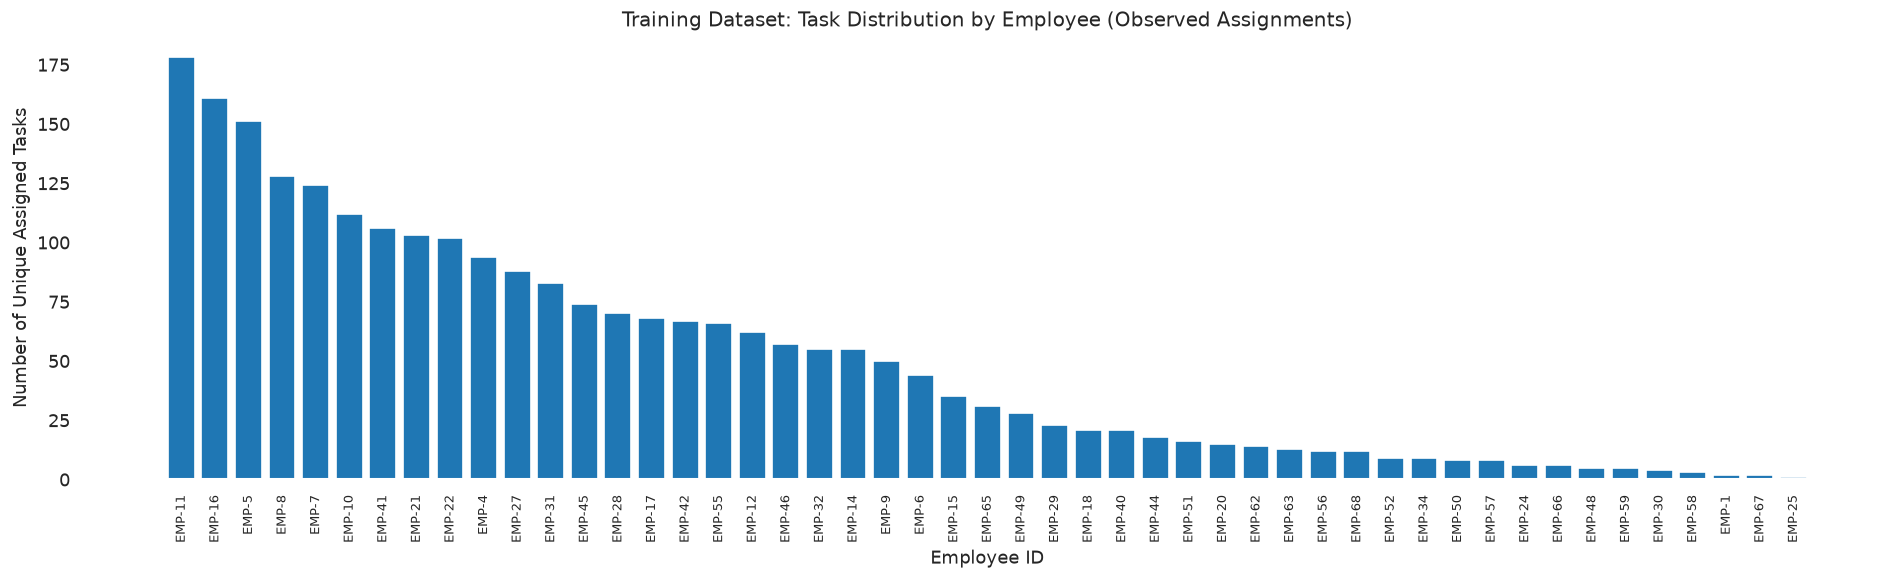

Note: High task count reflects observed workload, availability, or assignment behavior.
Do not interpret task count as a measure of employee ability.
Employees: 49, Max: 178, Min: 1


In [98]:
emp_task_dist = (
    pos_train
    .groupby("Employee_ID")["Task_ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Task_ID": "Task_Count"})
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(emp_task_dist["Employee_ID"].astype(str), emp_task_dist["Task_Count"], color="#1f77b4")
ax.set_xlabel("Employee ID", fontsize=11)
ax.set_ylabel("Number of Unique Assigned Tasks", fontsize=11)
ax.set_title("Training Dataset: Task Distribution by Employee (Observed Assignments)", fontsize=12)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.show()

print("Note: High task count reflects observed workload, availability, or assignment behavior.")
print("Do not interpret task count as a measure of employee ability.")
print(f"Employees: {emp_task_dist.shape[0]}, Max: {emp_task_dist["Task_Count"].max()}, Min: {emp_task_dist["Task_Count"].min()}")

## Step 16 — Sort by Task_ID and Compute Group Arrays

In [99]:
ltr_train = ltr_train.sort_values("Task_ID").reset_index(drop=True)
ltr_val   = ltr_val.sort_values("Task_ID").reset_index(drop=True)
ltr_test  = ltr_test.sort_values("Task_ID").reset_index(drop=True)

train_group_sizes = ltr_train.groupby("Task_ID", sort=False).size().to_numpy()
val_group_sizes   = ltr_val.groupby("Task_ID",   sort=False).size().to_numpy()
test_group_sizes  = ltr_test.groupby("Task_ID",  sort=False).size().to_numpy()

assert train_group_sizes.sum() == len(ltr_train)
assert val_group_sizes.sum()   == len(ltr_val)
assert test_group_sizes.sum()  == len(ltr_test)

with open(f"{OUTPUT_DIR}/train_group_sizes.json",      "w") as f: json.dump(train_group_sizes.tolist(), f)
with open(f"{OUTPUT_DIR}/validation_group_sizes.json", "w") as f: json.dump(val_group_sizes.tolist(), f)
with open(f"{OUTPUT_DIR}/test_group_sizes.json",       "w") as f: json.dump(test_group_sizes.tolist(), f)

print(f"Train groups: {len(train_group_sizes)}, mean size: {train_group_sizes.mean():.1f}")
print(f"Val groups:   {len(val_group_sizes)}, mean size: {val_group_sizes.mean():.1f}")
print(f"Test groups:  {len(test_group_sizes)}, mean size: {test_group_sizes.mean():.1f}")
print("Group size files saved.")

Train groups: 1709, mean size: 21.4
Val groups:   366, mean size: 21.4
Test groups:  367, mean size: 21.3
Group size files saved.


## Step 17 — Save LTR Datasets

In [100]:
ltr_train.to_csv(f"{OUTPUT_DIR}/ltr_train_dataset.csv",      index=False)
ltr_val.to_csv(f"{OUTPUT_DIR}/ltr_validation_dataset.csv",   index=False)
ltr_test.to_csv(f"{OUTPUT_DIR}/ltr_test_dataset.csv",        index=False)

ltr_feature_meta = {
    "feature_cols":             FEATURE_COLS,
    "n_features":               len(FEATURE_COLS),
    "task_skill_cols":          TASK_SKILL_COLS_PRESENT,
    "emp_hist_cols":            EMP_HIST_COLS,
    "emp_skill_profile_cols":   EMP_SKILL_MERGE_COLS,
    "compatibility_cols":       ["employee_task_skill_match_count","employee_task_skill_match_ratio","employee_has_matching_skill"],
    "project_exp_cols":         ["employee_project_task_count","employee_has_project_experience"],
    "n_train_tasks":            int(ltr_train["Task_ID"].nunique()),
    "n_val_tasks":              int(ltr_val["Task_ID"].nunique()),
    "n_test_tasks":             int(ltr_test["Task_ID"].nunique()),
    "n_employees":              N_EMPLOYEES,
    "negatives_per_task":       NEGATIVES_PER_TASK,
    "cold_start_employees":     cold_start_summary,
    "created_at":               datetime.datetime.now().isoformat(),
}
with open(f"{OUTPUT_DIR}/ltr_feature_columns.json", "w") as f:
    json.dump(ltr_feature_meta, f, indent=2)

print("=" * 60)
print("NOTEBOOK 05 OUTPUT SUMMARY")
print("=" * 60)
print(f"ltr_train_dataset.csv:      {ltr_train.shape}")
print(f"ltr_validation_dataset.csv: {ltr_val.shape}")
print(f"ltr_test_dataset.csv:       {ltr_test.shape}")
print(f"employee_candidate_pool.csv: {candidate_pool.shape}")
print(f"ltr_feature_columns.json:   {len(FEATURE_COLS)} features")
print(f"group_sizes: train={len(train_group_sizes)}, val={len(val_group_sizes)}, test={len(test_group_sizes)}")
display(ltr_train[["Task_ID","Employee_ID","relevance"] + FEATURE_COLS[:5]].head(3))

NOTEBOOK 05 OUTPUT SUMMARY
ltr_train_dataset.csv:      (36605, 65)
ltr_validation_dataset.csv: (7829, 65)
ltr_test_dataset.csv:       (7827, 65)
employee_candidate_pool.csv: (49, 2)
ltr_feature_columns.json:   56 features
group_sizes: train=1709, val=366, test=367


,Task_ID,Employee_ID,relevance,Hours_Spent,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,Task_Text_Length
0,TSK-1,EMP-44,1,4.0,0.0,23.0,8,328
1,TSK-1,EMP-46,1,4.0,0.0,23.0,8,328
2,TSK-1,EMP-1,1,4.0,0.0,23.0,8,328
